![Architecture of LeNet-5](figures/LeNet-5_Figure.png "LeNet-5")

## ***Environment Setup and Data Preparation***
#### In this sections, I set up the Environment, load the datasets (CIFAR-10 and MNIST), compute basic statistics and apply normalization.

### Environment Setup

In [1]:
%matplotlib inline
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

from statistics import mean
import numpy as np
import random
import time

### Data Loading & Basic Inspection

In [148]:
def load_cifar(root='../cnn_scratch_nieNazwa/data', transform=transforms.ToTensor()):
    train_set = torchvision.datasets.CIFAR10(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.CIFAR10(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [152]:
def load_mnist(root='../cnn_scratch_nieNazwa/data', transform=transforms.ToTensor()):    
    train_set = torchvision.datasets.MNIST(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.MNIST(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [149]:
train_data, val_data = load_cifar()

In [153]:
train_mnist, val_mnist = load_mnist()

### ***CIFAR-10:***

#### 50k training examples & 10k validation examples

In [150]:
len(train_data), len(val_data)

(50000, 10000)

#### Each sample is in the form (image, label), where the image is a ***3-channel (RGB) 32×32 image***

In [173]:
len(train_data[0]), len(val_data[0])

(2, 2)

In [172]:
train_data[0][0].shape, train_data[0][1], '|', val_data[0][0].shape, val_data[0][1]

(torch.Size([3, 32, 32]), 6, '|', torch.Size([3, 32, 32]), 3)

### ***MNIST:***

#### 60k training examples & 10k validation examples

In [154]:
len(train_mnist), len(val_mnist)

(60000, 10000)

#### Each sample is in the form (image, label), where the image is a ***1-channel (Grayscale) 28×28 image***

In [174]:
len(train_mnist[0]), len(val_mnist[0])

(2, 2)

In [175]:
train_mnist[0][0].shape, train_mnist[0][1], '|', val_mnist[0][0].shape, val_mnist[0][1]

(torch.Size([1, 28, 28]), 5, '|', torch.Size([1, 28, 28]), 7)

### Calculating Basic Statistics and Applying Normalization

#### `Stats_PerChannel` stacks all images from training dataset into a single tensor and calculates:
- #### **min & max** pixel values for each channel to check for potential anomalies  
- #### **mean & std** requiered for normalizing the dataset

In [6]:
def Stats_PerChannel(data, get=False):
    imgs = torch.stack([img for img, _ in data])
    
    min_vals = imgs.amin(dim=(0, 2, 3))
    max_vals = imgs.amax(dim=(0, 2, 3))
    print(f"Min vals: {min_vals}\tMax vals: {max_vals}\n")
    
    means = torch.mean(imgs, dim=(0, 2, 3))
    stds = torch.std(imgs, dim=(0, 2, 3))
    print(f"Mean: {means}\tStd: {stds}")

    if get:
        m = tuple(round(x, 5) for x in means.tolist())
        s = tuple(round(x, 5) for x in stds.tolist())
        return m, s

### ***CIFAR-10:***

#### Pixel values are within the expected range - *[0, 1]*

In [176]:
norm_mean, norm_std = Stats_PerChannel(train_data, get=True)

Min vals: tensor([0., 0., 0.])	Max vals: tensor([1., 1., 1.])

Mean: tensor([0.4914, 0.4822, 0.4465])	Std: tensor([0.2470, 0.2435, 0.2616])


In [177]:
norm_mean, norm_std

((0.4914, 0.48216, 0.44653), (0.24703, 0.24349, 0.26159))

#### CIFAR-10 dataset is reloaded with normalization applied using the computed mean and std

In [178]:
train_data, val_data = load_cifar(transform=transforms.Compose([transforms.ToTensor(),
     transforms.Normalize(norm_mean, norm_std)]))

#### After normalization, pixel values have mean ≈ 0 and standard deviation = 1 across all channels.</p> This ensures that no feature will dominate due to scale differences

In [179]:
Stats_PerChannel(train_data)

Min vals: tensor([-1.9892, -1.9802, -1.7070])	Max vals: tensor([2.0589, 2.1267, 2.1158])

Mean: tensor([-1.2720e-06, -6.4988e-06,  3.4809e-06])	Std: tensor([1.0000, 1.0000, 1.0000])


### ***MNIST:***

#### Pixel values are within the expected range - *[0, 1]*

In [180]:
mnist_mean, mnist_std = Stats_PerChannel(train_mnist, get=True)

Min vals: tensor([0.])	Max vals: tensor([1.])

Mean: tensor([0.1307])	Std: tensor([0.3081])


In [181]:
mnist_mean, mnist_std

((0.13066,), (0.30811,))

#### Since LeNet-5 takes 32x32 inputs, MNIST images are reshaped and normalzied with the computed mean and std 

In [182]:
train_mnist, val_mnist = load_mnist(transform=transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)]))

#### Since MNIST images are mostly composed of a black background, the value range may not be perfectly symmetric 
#### After normalization, pixel values have mean ≈ 0 and standard deviation ≈ 1

In [183]:
Stats_PerChannel(train_mnist)

Min vals: tensor([-0.4241])	Max vals: tensor([2.8215])

Mean: tensor([0.0008])	Std: tensor([0.9389])


## Dataset Visualization

### Creating Functions for Visualization

In [184]:
def define_labels(set_name):
    if set_name == 'mnist':
        return {i: i for i in range(0, 10)}
    else:
        return {0: 'plane', 1: 'car', 2: 'bird', 3: 'cat', 4: 'deer', 
           5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

#### Since both datasets are normalized, `imshow` denormalizes the images before visualization

In [188]:
def imshow(img, lbl, m, s):
    mean, std = torch.tensor(m), torch.tensor(s)
    img = img * std[:, None, None] + mean[:, None, None]   
    img.clamp_(0, 1)
    
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(lbl)

#### `viz_random` visualizes 20 random images from the given dataset

In [189]:
def viz_random(data, set_name, m, s):
    rand_idx = random.sample(range(0, len(data)), 20)
    classes = define_labels(set_name)
    
    figure = plt.figure(figsize=(12, 3), tight_layout=True)

    for i, idx  in enumerate(rand_idx):
        img, label = data[idx]
        figure.add_subplot(2, 10, i+1)
        imshow(img, classes[label], m, s)
    plt.show()

### ***CIFAR-10:***

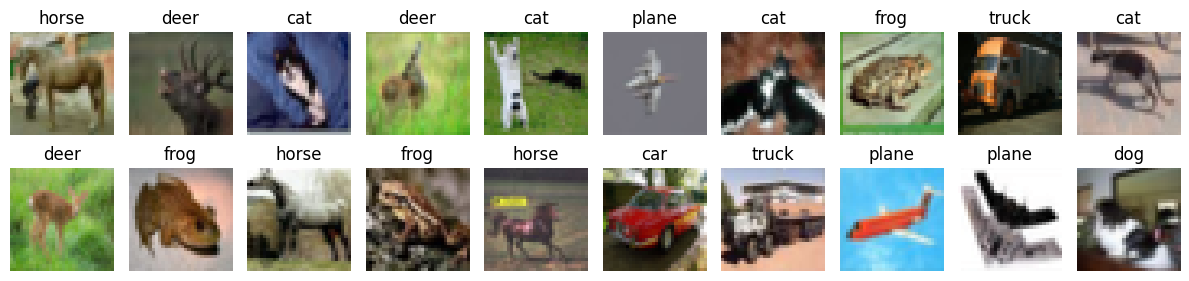

In [191]:
viz_random(train_data, 'cifar', norm_mean, norm_std)

### ***MNIST:***

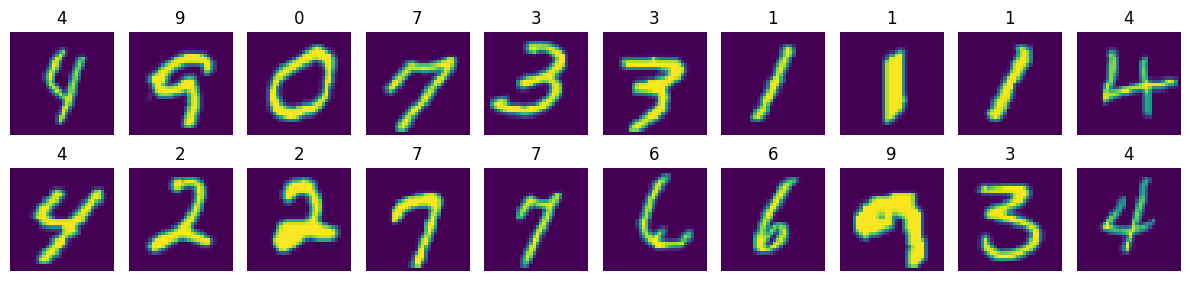

In [192]:
viz_random(train_mnist, 'mnist', mnist_mean, mnist_std)

## Architecture

<center>
  <img src="figures/LeNet-5_Figure.png" width="750">
</center>

### Cross-Coorelation

#### Since LeNet does not implement padding and stride above 1 in any convolutional layer we may calculate output shape by simple formula:
- #### Number of Filters, (Input_height - Kernel_height + 1), (Input_width - Kernel_width + 1) - do poprawy

## Pack That shit in The class !!!!!

### I didn't want to just call nn.Conv2d() and treat it like a black box. This is my "from-scratch" implementation of the LeNet-5 architecture, focusing on the actual tensor logic behind convolutional layers.
#### This is my understanding and method

In [4]:
"""Conv Layer Class"""

'Conv Layer Class'

In [15]:
class PoolLayer(nn.Module):
    def __init__(self, k_size, stride, p_type, device):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.stride = stride
        self.device = device
        
        """ Setting Pooling function """
        if p_type == 'avg':
            self.func = torch.mean
        else:
            self.func = torch.amax

    def forward(self, X):
        X_batch, X_c, X_h, X_w = X.shape[0], X.shape[1], X.shape[2], X.shape[3]
        Y = torch.zeros(X_batch, X_c, (X_h - self.K_h)//self.stride + 1,
                        (X_w - self.K_w)//self.stride + 1, device=self.device)

        for i, i_x in enumerate(range(0, X_h - self.K_h + 1, self.stride)):
            for j, j_x in enumerate(range(0, X_w - self.K_w + 1, self.stride)):
                x_slice = X[:, :, i_x: i_x + self.K_h, j_x: j_x + self.K_w]
                Y[:, :, i, j] = self.func(x_slice, dim=(2, 3))
                
        return Y

In [16]:
class LinearLayer(nn.Module):
    def __init__(self, num_in, num_out):
        super().__init__()

        """ He Kaiming Initialization """
        std = np.sqrt(2.0 / num_in)

        """ Defining Parameters """
        self.W = torch.nn.Parameter(torch.randn(num_in, num_out) * std)
        self.b = torch.nn.Parameter(torch.zeros(num_out))

    def forward(self, X):
        return torch.matmul(X, self.W) + self.b

In [17]:
class ConvLayer(nn.Module):
    def __init__(self, k_size, num_in, num_out, device):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.K_c = num_out
        self.device = device
        
        """ He Kaiming Initialization """
        fan_in = num_in * self.K_h * self.K_w
        std = np.sqrt(2.0 / fan_in)

        """ Defining Parameters """
        self.K = torch.nn.Parameter(
            torch.randn(self.K_c, num_in, self.K_h, self.K_w) * std)
        
        self.b = torch.nn.Parameter(torch.zeros(num_out, 1, 1))

    def forward(self, X):
        X_batch, X_h, X_w = X.shape[0], X.shape[2], X.shape[3]
        Y = torch.zeros(X_batch, self.K_c, X_h - self.K_h + 1, X_w - self.K_w + 1, device=self.device)
        
        for i in range(Y.shape[2]):
            for j in range(Y.shape[3]):
                x_slice = X[:, :, i: i+self.K_h, j: j+self.K_w]         
                Y[:, :, i, j] = (x_slice.unsqueeze(dim=1) * self.K).sum(dim=(2, 3, 4))
                
        return Y + self.b 

In [75]:
class LeNet_5(nn.Module):
    def __init__(self, lr, device, in_channels=3, p_type='avg'):
        super().__init__()
        self.lr = lr
        self.device = device
        self.p_type = p_type

        self.Conv_1 = ConvLayer(k_size=(5, 5), num_in=in_channels, num_out=6, device=self.device)
        self.Pool_1 = PoolLayer(k_size=(2, 2), stride=2, p_type=self.p_type, device=self.device)
        self.Conv_2 = ConvLayer(k_size=(5, 5), num_in=6, num_out=16, device=self.device)
        self.Pool_2 = PoolLayer(k_size=(2, 2), stride=2, p_type=self.p_type, device=self.device)
        
        self.Linear_1 = LinearLayer(num_in=400, num_out=120)
        self.Linear_2 = LinearLayer(num_in=120, num_out=84)
        self.Linear_3 = LinearLayer(num_in=84, num_out=10)

    def forward(self, X):
        X = self.Pool_1(F.relu(self.Conv_1(X)))
        X = self.Pool_2(F.relu(self.Conv_2(X)))
        X = X.reshape(X.shape[0], -1)
        X = F.relu(self.Linear_2(F.relu(self.Linear_1(X))))
        return self.Linear_3(X)

    def ce_loss(self, Y_hat, Y):
        return F.cross_entropy(Y_hat, Y, reduction='mean')

    def config_optim(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)
        
    def batch_step(self, batch):
        X, y = batch
        X, y = X.to(self.device), y.to(self.device)
        
        Y_hat = self.forward(X)
        l = self.ce_loss(Y_hat, y)
        acc = (Y_hat.argmax(dim=1) == y).float().mean()
        return l, acc.item()

In [19]:
def data_loader(data, is_train, batch_size):
    return torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=is_train, num_workers=2)

In [20]:
class Trainer():
    def __init__(self, num_epochs, batch_size):
        self.num_epochs = num_epochs
        self.batch_size = batch_size

    def plotter_init(self, title):
        self.plotter = Plotter(title)

    def prepare_data(self, train_data, val_data):
        self.train_dataloader = data_loader(train_data, True, self.batch_size)
        self.val_dataloader = data_loader(val_data, False, self.batch_size)
  
    def fit(self, model, train_data, val_data):
        self.prepare_data(train_data, val_data) 
        self.model = model
        self.optim = model.config_optim()
        
        for epoch in range(self.num_epochs):
            self.fit_epoch(epoch+1)

    def fit_epoch(self, n_epoch):
        train_loss, val_loss, val_acc = [], [], []
        self.model.train()
        pbar_train = tqdm(self.train_dataloader, desc=f"Epoch: {n_epoch} [Train]", leave=True)
        
        for batch in pbar_train:
            loss, _ = self.model.batch_step(batch)     
            self.optim.zero_grad()
            loss.backward()
            self.optim.step()
            
            train_loss.append(loss.item())
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")
            
        self.model.eval()
        pbar_val = tqdm(self.val_dataloader, desc=f"Epoch: {n_epoch} [Val]", leave=True)
        
        for batch in pbar_val:
            with torch.no_grad():
                loss, acc = self.model.batch_step(batch)
                
                val_loss.append(loss.item())
                val_acc.append(acc)
                pbar_val.set_postfix(acc=f"{acc:.2f}")
                
        self.plotter.plot(mean(train_loss), mean(val_loss), mean(val_acc))

In [21]:
class Plotter():
    def __init__(self, title):
        self.title = title
        self.train_losses = []
        self.val_losses = []
        self.val_acc = []
        self.epoch = 0

    def update_stats(self, train_loss, val_loss, acc):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.val_acc.append(acc)
        self.epoch += 1

    def plot(self, train_loss, val_loss, acc):
        self.update_stats(train_loss, val_loss, acc)
        epochs = range(1, self.epoch + 1)
        
        clear_output(wait=True) 
        plt.figure(figsize=(6,4), constrained_layout=True)
        plt.plot(epochs, self.train_losses, label=f"Train loss: {self.train_losses[-1]:.4f}")
        plt.plot(epochs, self.val_losses, label=f"Val loss: {self.val_losses[-1]:.4f}")
        plt.plot(epochs, self.val_acc, linestyle="-.", label=f"Val acc: {self.val_acc[-1]:.4f}")
        plt.xlabel("Epoch")
        plt.title(self.title)
        plt.legend()
        plt.show()

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [82]:
model_cifar1 = LeNet_5(lr=0.1, device=device, in_channels=3, p_type='avg')
model_cifar1.to('cuda')

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

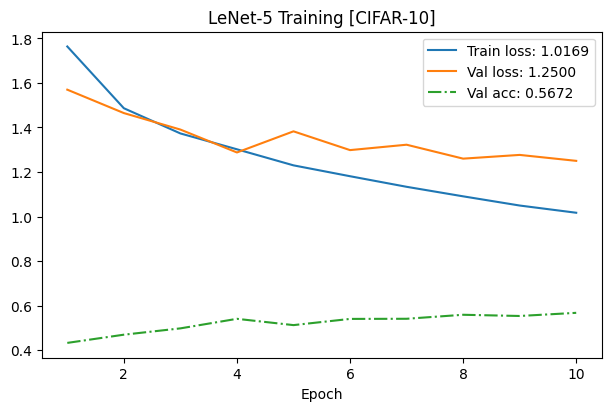

In [83]:
trainer_cifar1 = Trainer(num_epochs=10, batch_size=128)
trainer_cifar1.plotter_init("LeNet-5 Training [CIFAR-10]")
trainer_cifar1.fit(model_cifar1, train_data, val_data)

In [194]:
torch.save(model_cifar1.state_dict(), "lenet_cifar1.pth")

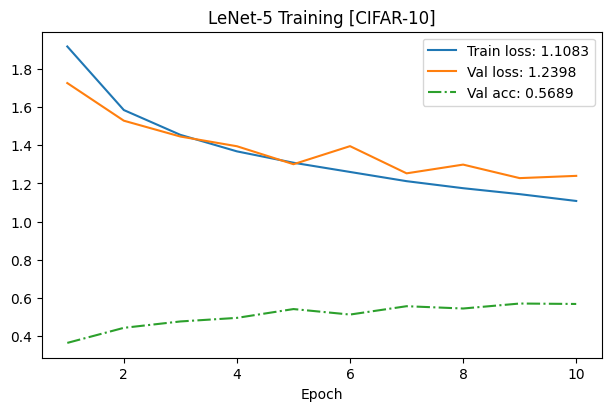

In [84]:
model_cifar2 = LeNet_5(lr=0.1, device=device, in_channels=3, p_type='max')
model_cifar2.to('cuda')
trainer_cifar2 = Trainer(num_epochs=10, batch_size=128)
trainer_cifar2.plotter_init("LeNet-5 Training [CIFAR-10]")
trainer_cifar2.fit(model_cifar2, train_data, val_data)

In [195]:
torch.save(model_cifar2.state_dict(), "lenet_cifar2.pth")

In [29]:
model_2 = LeNet_5(lr=0.1, device=device, in_channels=1)
model_2.to(device)

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

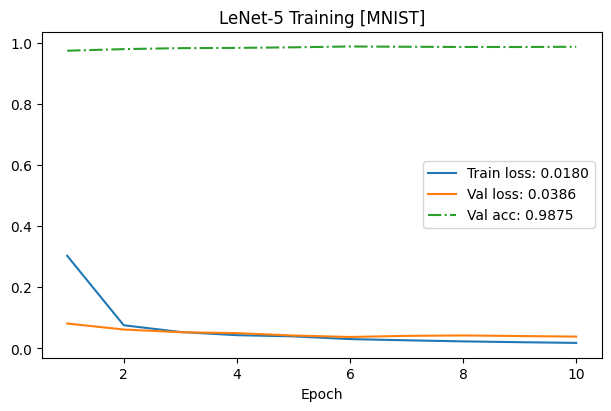

In [30]:
trainer = Trainer(num_epochs=10, batch_size=128)
trainer.plotter_init("LeNet-5 Training [MNIST]")
trainer.fit(model_2, train_mnist, val_mnist)

In [196]:
torch.save(model_2.state_dict(), "lenet_mnist1.pth")

In [76]:
model_3 = LeNet_5(lr=0.1, device=device, in_channels=1, p_type='max')
model_3.to(device)

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

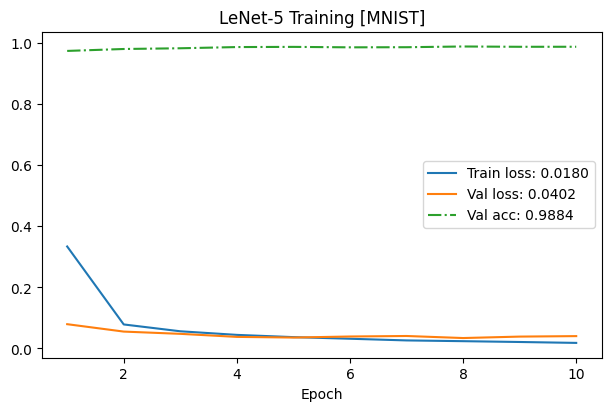

In [77]:
trainer_3 = Trainer(num_epochs=10, batch_size=128)
trainer_3.plotter_init("LeNet-5 Training [MNIST]")
trainer_3.fit(model_3, train_mnist, val_mnist)

In [197]:
torch.save(model_3.state_dict(), "lenet_mnist2.pth")

# zwizualizuj Filtry

In [125]:
def define_labels(set_name):
    if set_name == 'mnist':
        return {i: i for i in range(0, 10)}
    else:
        return {0: 'plane', 1: 'car', 2: 'bird', 3: 'cat', 4: 'deer', 
           5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

In [139]:
def mapshow(img, lbl):
    img = (img - img.min()) / (img.max() - img.min() + 1e-5)
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(lbl)

In [137]:
def viz_Conv1(batch, model, set_name):
    X_data, y_data = batch
    dist_lbl, dist_idx = np.unique(y_data, return_index=True)
    classes = define_labels(set_name)
    
    figure = plt.figure(figsize=(12, 9), tight_layout=True)

    with torch.no_grad():
        layer = model.Conv_1
        layer_out = layer.forward(X_data.to('cuda')).to('cpu')
        
        for c in range(layer.K_c):
            for i, (label, idx) in enumerate(zip(dist_lbl, dist_idx)):
                img = layer_out[idx, c]
                figure.add_subplot(6, 10, (i+1)+10*c)
                title = str(classes[label])             
                if label == dist_lbl[0]:
                    title = f"[Filter: {c+1}]  {title}"
                
                mapshow(img, title)
    plt.show()

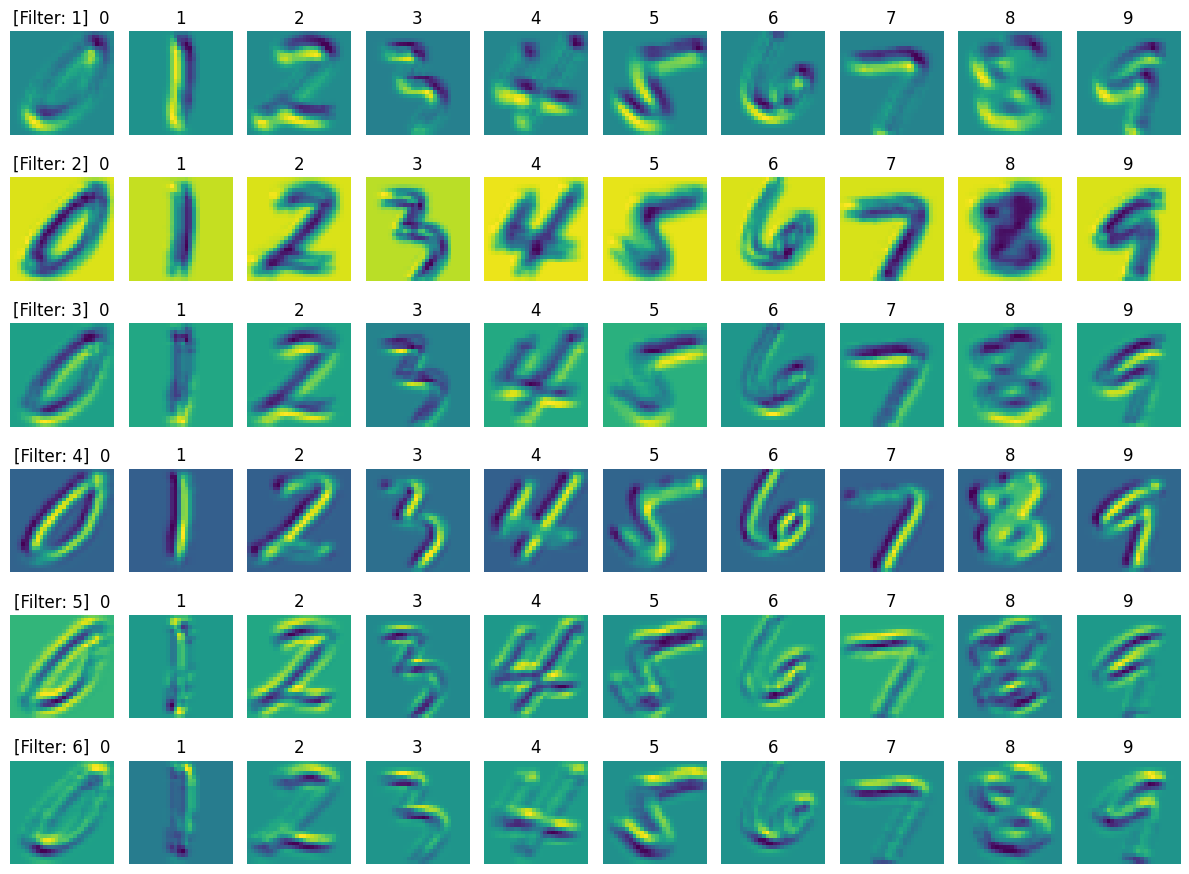

In [140]:
viz_Conv1(next(iter(data_loader(train_mnist, True, 64))), model_2, 'mnist')

In [141]:
def viz_Conv2(batch, model, set_name):
    X_data, y_data = batch
    dist_lbl, dist_idx = np.unique(y_data, return_index=True)
    classes = define_labels(set_name)
    
    figure = plt.figure(figsize=(12, 9), tight_layout=True)

    with torch.no_grad():
        layer = model.Conv_2
        layer_in = model.Pool_1.forward(model.Conv_1.forward(X_data.to('cuda')))
        layer_out = layer.forward(layer_in).to('cpu')
        
        for idc, c in enumerate(range(0, layer.K_c, 3)):
            for i, (label, idx) in enumerate(zip(dist_lbl, dist_idx)):
                img = layer_out[idx, c]
                figure.add_subplot(6, 10, (i+1)+10*idc)
                title = str(classes[label])
                if label == dist_lbl[0]:
                    title = f"[Filter: {c+1}]  {title}"
                
                mapshow(img, title)
    plt.show()

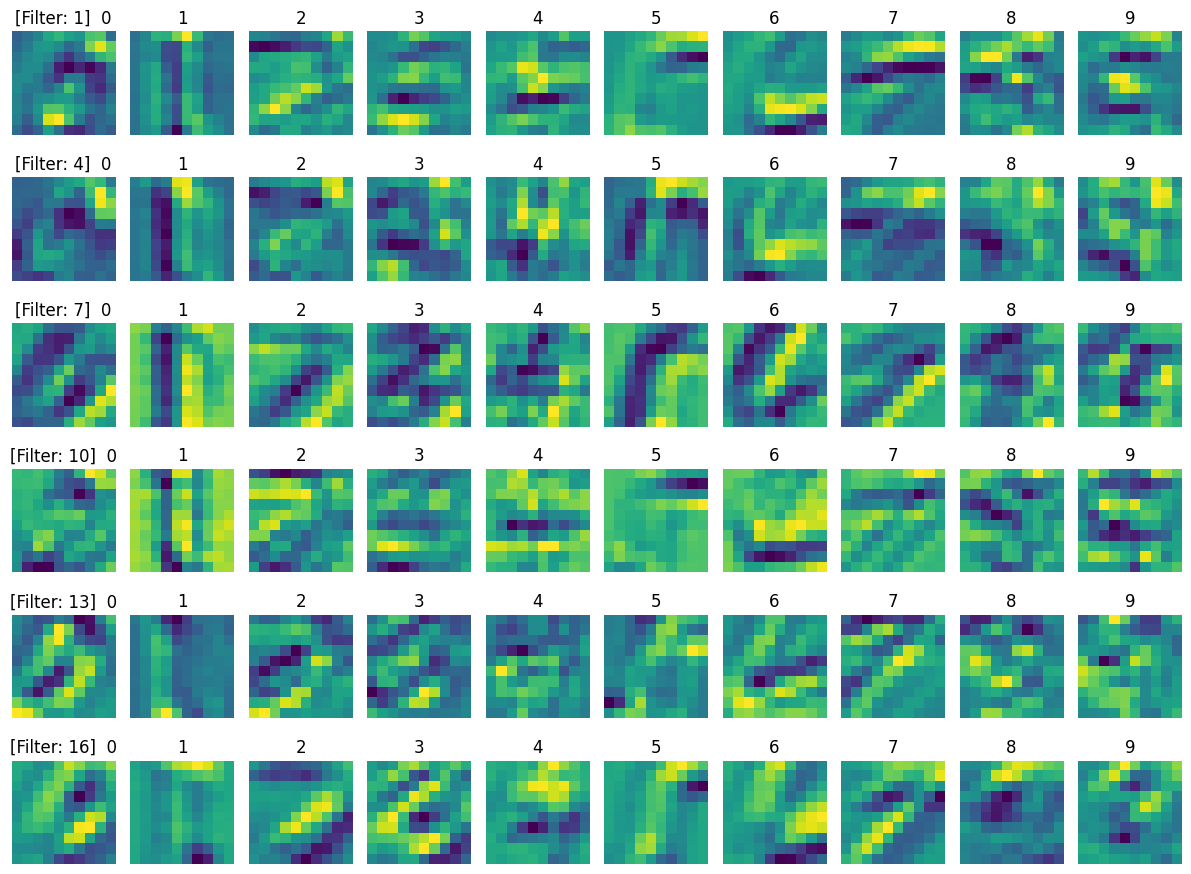

In [143]:
viz_Conv2(next(iter(data_loader(train_mnist, True, 64))), model_2, 'mnist')

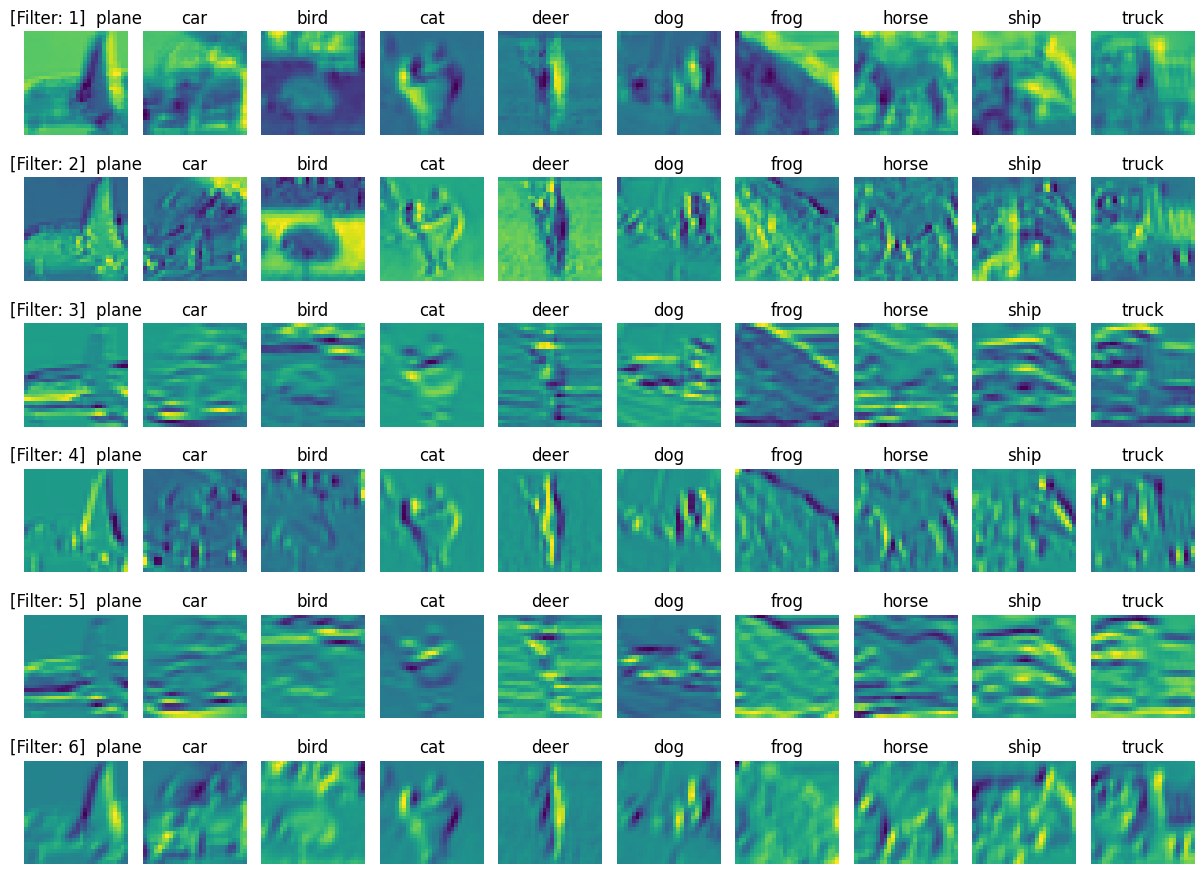

In [144]:
viz_Conv1(next(iter(data_loader(train_data, True, 64))), model_cifar1, 'cifar')

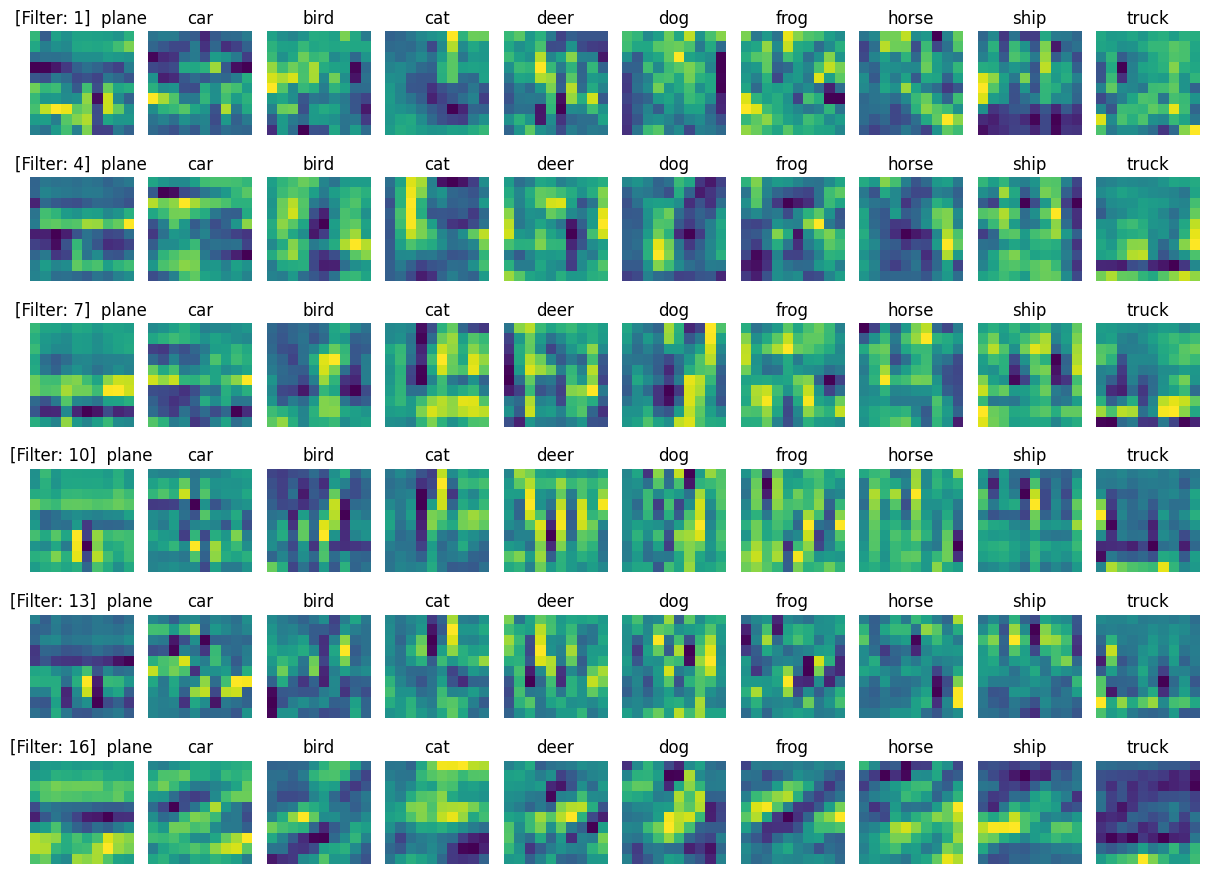

In [145]:
viz_Conv2(next(iter(data_loader(train_data, True, 64))), model_cifar1, 'cifar')

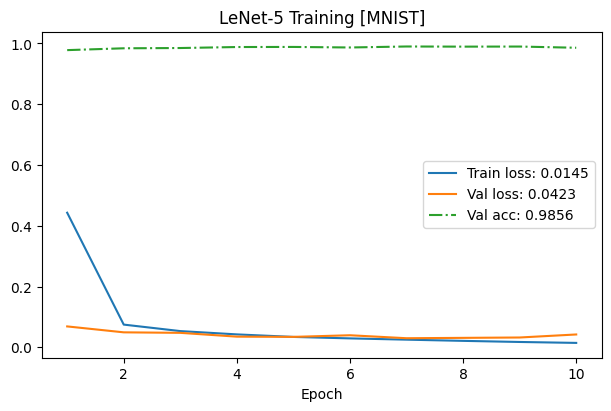

In [116]:
model_api = LeNet_API(0.1, 10, device)
model_api.to(device)
trainer = Trainer(num_epochs=10, batch_size=128)
trainer.plotter_init("LeNet-5 Training [MNIST]")
trainer.fit(model_api, train_mnist, val_mnist)

In [45]:
def layer_summary(X_shape, model):
    X = torch.randn(*X_shape, device='cuda')
    for layer in model.net:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [35]:
class LeNet_API(nn.Module):
    """The LeNet-5 model."""
    def __init__(self, lr=0.1, num_classes=10, device='cuda'):
        super().__init__()
        self.lr = lr
        self.num_classes = num_classes
        self.device = device
        
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(self.num_classes))

    def forward(self, X):
        return self.net(X)

    def ce_loss(self, Y_hat, Y):
        return F.cross_entropy(Y_hat, Y, reduction='mean')

    def config_optim(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)
        
    def batch_step(self, batch):
        X, y = batch
        X, y = X.to(self.device), y.to(self.device)
        
        Y_hat = self.forward(X)
        l = self.ce_loss(Y_hat, y)
        acc = (Y_hat.argmax(dim=1) == y).float().mean()
        return l, acc.item()

In [298]:
tic = time.time()
for X, y in data_loader(train_data, True, 256):
    continue
f'{time.time() - tic:.2f} sec'

'11.25 sec'